<a href="https://colab.research.google.com/github/DIFACQUIM/antiviral_ML/blob/main/3_screening_curation/03_Cured_of_viralDB_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **Packages**: installation and importation
---

In [ ]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        from tqdm import tqdm
        pbar.update(20)
        !pip install matplotlib, seaborn, pandas
        '''Librerías gráficas'''
        import matplotlib.pyplot as plt
        from matplotlib_venn import venn3, venn3_circles, venn3_unweighted

        from IPython.display import display, SVG, HTML
        import seaborn as sns
        pbar.update(40)
        '''Librerias de herramientas primarias:'''
        import pandas as pd
        import numpy as np
        pbar.update(30)
        '''Librerias de quimioinformatica'''
        !pip install molvs
        !pip install datamol
        !pip install rdkit
        from rdkit import Chem, DataStructs, RDConfig
        from rdkit.Chem import Draw, Descriptors, AllChem, PandasTools, Descriptors3D, rdMolDescriptors, Scaffolds,MACCSkeys
        from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
        from rdkit.DataManip.Metric.rdMetricMatrixCalc import GetTanimotoSimMat, GetTanimotoDistMat
        PandasTools.RenderImagesInAllDataFrames(images=True)
        from rdkit.Chem.Draw import IPythonConsole
        import datamol as dm
        dm.disable_rdkit_log()
        from molvs.standardize import Standardizer
        from molvs.charge import Uncharger, Reionizer
        from molvs.fragment import LargestFragmentChooser
        from molvs.tautomer import TautomerCanonicalizer
        from google.colab import drive
        drive.mount('/content/drive')
        pbar.update(10)

  0%|          | 0/100 [00:00<?, ?it/s]

ValueError: mount failed

---

# **1. Cured of antivirals compounds DB:**


---

In [ ]:
def extraction_zip(file, password):
  '''
  Extraccion of files inside of .zip format.
  file = name of the file.
  password = key to extract the file... None

  '''
  ruta_zip = "/content/drive/MyDrive/Proyectos/G9a/Focused_libraries/Bibliotecas_zip/Archivos_zip/"+file+".zip"
  ruta_extraccion = "/content/drive/MyDrive/Proyectos/G9a/Focused_libraries/Bibliotecas_zip/Archivos_extraidos"
  password = password #None
  archivo_zip = zipfile.ZipFile(ruta_zip, "r")
  try:
      print(archivo_zip.namelist())
      archivo_zip.extractall(pwd=password, path=ruta_extraccion)
  except:
      pass
  archivo_zip.close()

def extract_info_from_sdf(path_direction, file, name):
  table_name = f"table_{name}" #Name of the table
  sdf_file_path = os.path.join(RDConfig.RDDataDir,path_direction+file+'.sdf') #Path of the SDF file
  # Load SDF file into DataFrame
  table = PandasTools.LoadSDF(sdf_file_path, smilesName='SMILES', molColName='Molecule', includeFingerprints=True) #Carga el archivo SDF en un DataFrame de Pandas.
  print(f"{table_name} shape: {table.shape}. DataFrame columns: {table.columns}")
  return table

def read_db(path_direction, file, format, name=None):
    file_path = os.path.join(path_direction, file + format)
    tqdm.pandas(desc="Reading File")

    if format == '.csv':
        dataframe = pd.read_csv(file_path, sep=',')
        tqdm.pandas(desc="Processing CSV")
        dataframe.progress_apply(lambda x: x, axis=1)
        print(f"{name} shape: {dataframe.shape}. DataFrame columns: {dataframe.columns}")

    elif format == '.xlsx':
        dataframe = pd.read_excel(file_path, index_col=0)
        tqdm.pandas(desc="Processing Excel")
        dataframe.progress_apply(lambda x: x, axis=1)
        print(f"{name} shape: {dataframe.shape}. DataFrame columns: {dataframe.columns}")

    elif format == '.sdf':
        dataframe = extract_info_from_sdf(path_direction, file, name)
        tqdm.pandas(desc="Processing SDF")
        dataframe.progress_apply(lambda x: x, axis=1)

    return dataframe

---

## **1.1 SET 1:**


---

In [ ]:
path_db= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/'
#ChemDiv
db_virus_1 = 'Download_SDF_CORONAVIRUS_Library_20750' #sdf--Coronavirus Library--https://www.chemdiv.com/catalog/focused-and-targeted-libraries/coronavirus-library/
db_virus_2 = 'Antiviral-Library-64958'#sdf--Antiviral Library--https://www.chemdiv.com/catalog/focused-and-targeted-libraries/antiviral-library/
#OTAVA
db_virus_3 = 'OTAVA_Drug-Like_Green_Collection' #csv--Drug-Like Green collection--https://www.otavachemicals.com/products/compound-libraries-for-hts/drug-like-green-collection
#Enamine
db_virus_4 = 'Enamine_Antiviral_Library_3200cmpds_20240723' #csv--Antiviral Library--https://enamine.net/compound-libraries/targeted-libraries/antiviral-library?highlight=WyJhbnRpdmlyYWwiXQ==

#Tocriscreen™ PRO Custom Compound Library Service ---https://www.tocris.com/about-tocris/tocriscreen-pro-custom-compound-library-service
#Vitas M --- https://vitasmlab.biz/special-databases

db1=read_db(path_db, db_virus_1, '.sdf', 'DB1') #(20750, 23)
db2=read_db(path_db, db_virus_2, '.sdf', 'DB2') #(64958, 30)
db3=read_db(path_db, db_virus_3, '.sdf', 'DB3') #(169658, 10)
db4=read_db(path_db, db_virus_4, '.sdf', 'DB4') #(3200, 12)

table_DB1 shape: (20750, 23). DataFrame columns: Index(['IDNUMBER', 'available', 'H_acceptor', 'H_donor', 'B_rotN', 'N_O',
       'logP', 'logD', 'logSw', 'PSA', 'Name', 'Smile', 'Collection', 'InChI',
       'InChI Key', 'PERCENTSP3', 'Link', 'CHIRAL', 'ID', 'SMILES', 'Molecule',
       'CLNUMBER', 'Saltdata'],
      dtype='object')


Processing SDF: 100%|██████████| 20750/20750 [00:01<00:00, 14942.96it/s]


table_DB2 shape: (64958, 30). DataFrame columns: Index(['IDNUMBER', 'available', 'H_acceptor', 'H_donor', 'B_rotN', 'N_O',
       'logP', 'logD', 'logSw', 'PSA', 'pKa_ma', 'pKa_mb', 'N_Chirals', 'Name',
       'Smile', 'Color', 'Collection', 'InChI', 'InChI Key', 'PERCENTSP3',
       'Link', 'CLNUMBER', 'Saltdata', 'Saltdata_MW', 'STEREO', 'State', 'ID',
       'SMILES', 'Molecule', 'CAS'],
      dtype='object')


Processing SDF: 100%|██████████| 64958/64958 [00:04<00:00, 13934.24it/s]


table_DB3 shape: (169658, 10). DataFrame columns: Index(['Code', 'Number of H-Donors', 'Number of H-Acceptors',
       'Number of Rotatable bonds', 'CLogP', 'nRings', 'ID', 'SMILES',
       'Molecule', 'Saltdata'],
      dtype='object')


Processing SDF: 100%|██████████| 169658/169658 [00:11<00:00, 14148.81it/s]


table_DB4 shape: (3200, 12). DataFrame columns: Index(['Catalog ID', 'MW', 'MW (desalted)', 'ClogP', 'logS', 'HBD', 'HBA',
       'TPSA', 'RotBonds', 'ID', 'SMILES', 'Molecule'],
      dtype='object')


Processing SDF: 100%|██████████| 3200/3200 [00:00<00:00, 31008.41it/s]


In [ ]:
#Information
print(db1.info(), '\n')
print(db2.info(), '\n')
print(db3.info(), '\n')
print(db4.info(), '\n')

<class 'pandas.core.frame.DataFrame'>
Index: 20750 entries, 0 to 20749
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   IDNUMBER    20750 non-null  object
 1   available   20750 non-null  object
 2   H_acceptor  20750 non-null  object
 3   H_donor     20746 non-null  object
 4   B_rotN      20750 non-null  object
 5   N_O         20750 non-null  object
 6   logP        20748 non-null  object
 7   logD        20738 non-null  object
 8   logSw       20748 non-null  object
 9   PSA         20745 non-null  object
 10  Name        20750 non-null  object
 11  Smile       20750 non-null  object
 12  Collection  20750 non-null  object
 13  InChI       20750 non-null  object
 14  InChI Key   20750 non-null  object
 15  PERCENTSP3  20750 non-null  object
 16  Link        20750 non-null  object
 17  CHIRAL      20750 non-null  object
 18  ID          20750 non-null  object
 19  SMILES      20750 non-null  object
 20  Molecule   

---

## **1.2 SET 2:**


---

In [ ]:
import os
path_1='/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/LifeChemicals/'
path_2='/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/LifeChemicals/LC_EF1A_Targeted_Library_EF1B_GDP_sites/'
path_3='/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/LifeChemicals/LC_Pre-plated_Coronavirus_COVID-19_Screening_Set (1)/'
path_4='/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/LifeChemicals/LC_Preplated_Helicase_Screening_Set_6080cmpds/'

count=1
print(path_1)
for i in os.listdir(path_1):
  print(count, i)
  count+=1
print(path_2)
for i in os.listdir(path_2):
  count+=1
  print(count, i)
print(path_3)
for i in os.listdir(path_3):
  count+=1
  print(count, i)
print(path_5)
for i in os.listdir(path_4):
  count+=1
  print(count, i)

/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/LifeChemicals/
1 LC_Helicase_Targeted_Library.sdf
2 LC_Helicase_Focused_Library.sdf
3 LC_EF1A_Targeted_Library_EF1B_GDP_sites
4 LC_2019-nCoV_Papain-Like_Protease_Targeted_Library.sdf
5 LC_DNA_Polymerase_Targeted_Library.sdf
6 LC_Polymerase_Focused_Library_15_Polymerase_Assays.sdf
7 LC_Polymerase_Focused_Library_Similarity_to_ChEMBL_Database.sdf
8 LC_SARS_Coronavirus_Focused_Library.sdf
9 LC_2019-nCoV_Main_Protease_Targeted_Library.sdf
10 LC_Antiviral_Targeted_Library.sdf
11 LC_Merged_Antiviral_Screening_Superset.sdf
12 LC_Antiviral_Library_Combined_Ligand-Based_and_Structure-Based_Approaches.sdf
13 LC_Antiviral_Screening_Compound_Library_2D_Similarity.sdf
14 LC_Bioactive_Compound_Library.sdf
15 LC_Preplated_Helicase_Screening_Set_6080cmpds
16 LC_Pre-plated_Coronavirus_COVID-19_Screening_Set (1)
/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial librar

In [ ]:
path_db= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/Commercial libraries/'
#ChemSpace
db_virus_5 = 'Chemspace_Legacy_Diverse_Set_10k' #Discovery Diversity Set--https://chem-space.com/compounds/discovery_diversity_set?utm_medium=instagram&utm_term=DDS_set

#LifeChemicals
#path_1
db_virus_6 = 'LC_Helicase_Targeted_Library' #sdf
db_virus_7 = 'LC_Helicase_Focused_Library'#.sdf
db_virus_8 = 'LC_2019-nCoV_Papain-Like_Protease_Targeted_Library'#.sdf
db_virus_9 = 'LC_DNA_Polymerase_Targeted_Library'#.sdf
db_virus_10 = 'LC_Polymerase_Focused_Library_15_Polymerase_Assays'#.sdf
db_virus_11 = 'LC_Polymerase_Focused_Library_Similarity_to_ChEMBL_Database'#.sdf
db_virus_12 = 'LC_SARS_Coronavirus_Focused_Library'#.sdf
db_virus_13 = 'LC_2019-nCoV_Main_Protease_Targeted_Library'#.sdf
db_virus_14 = 'LC_Antiviral_Targeted_Library'#.sdf
db_virus_15 = 'LC_Merged_Antiviral_Screening_Superset'#.sdf
db_virus_16 = 'LC_Antiviral_Library_Combined_Ligand-Based_and_Structure-Based_Approaches'#.sdf
db_virus_17 = 'LC_Antiviral_Screening_Compound_Library_2D_Similarity'#.sdf
db_virus_18 = 'LC_Bioactive_Compound_Library'#.sdf
#Path_2
db_virus_19 = 'LC_EF1A_Targeted_Library_GDP_site'#.sdf
db_virus_20 = 'LC_EF1A_Targeted_Library_EF1B_site'#.sdf
#path_3
db_virus_21 = 'LC_Pre-plated_Coronavirus_COVID-19_Screening_Set-384_well'#.sdf
#path_4
db_virus_22 = 'LC_Preplated_Helicase_Screening_Set_6080cmpds_384well'#.sdf
db_virus_23 = 'LC_Preplated_Helicase_Screening_Set_6080cmpds_96well'#.sdf
'''
Helicase - 4/ PLP-nCov: 1 / DNA-pol: 3 /
SARS-CoV: 1 /SARS-Cov-2: 2 / Mpro: 1 / Others: 4 / Antiviral: 7
'''

db5=read_db(path_db, db_virus_5, '.sdf', 'DB5') #(10000, 5)

db6=read_db(path_1, db_virus_6, '.sdf', 'DB6') #(3291, 24).
db7=read_db(path_1, db_virus_7, '.sdf', 'DB7') # (3838, 23)
db8=read_db(path_1, db_virus_8, '.sdf', 'DB8') # (1736, 21).
db9=read_db(path_1, db_virus_9, '.sdf', 'DB9') #((628, 21).
db10=read_db(path_1, db_virus_10, '.sdf', 'DB10') # (15691, 17).
db11=read_db(path_1, db_virus_11, '.sdf', 'DB11') # (13610, 24)
db12=read_db(path_1, db_virus_12, '.sdf', 'DB12') #(437, 22).
db13=read_db(path_1, db_virus_13, '.sdf', 'DB13') #(2338, 18).
db14=read_db(path_1, db_virus_14, '.sdf', 'DB14') #(1350, 20)
db15=read_db(path_1, db_virus_15, '.sdf', 'DB15') #(45573, 18)
db16=read_db(path_1, db_virus_16, '.sdf', 'DB16') #(3514, 19).
db17=read_db(path_1, db_virus_17, '.sdf', 'DB17') #(15472, 26).
db18=read_db(path_1, db_virus_18, '.sdf', 'DB18') #(9898, 21)

db19=read_db(path_2, db_virus_19, '.sdf', 'DB19') #(1267, 22).
db20=read_db(path_2, db_virus_20, '.sdf', 'DB20') #(1544, 22).

db21=read_db(path_3, db_virus_21, '.sdf', 'DB21') # (2300, 23)

db22=read_db(path_4, db_virus_22, '.sdf', 'DB22') #(6080, 33)
db23=read_db(path_4, db_virus_23, '.sdf', 'DB23') #(6080, 33).

table_DB5 shape: (10000, 5). DataFrame columns: Index(['CHEMSPACE_ID', 'CHEMSPACE_URL', 'ID', 'SMILES', 'Molecule'], dtype='object')


Processing SDF: 100%|██████████| 10000/10000 [00:00<00:00, 10181.29it/s]


table_DB6 shape: (3291, 24). DataFrame columns: Index(['IDNUMBER', 'Chemical_Name', 'CAS', 'PriceCoeff', 'MW', 'Description',
       'FSP3', 'clogP', 'TPSA', 'Acceptor', 'Donor', 'RotBonds', 'HAC',
       'Collection', 'Target name', 'NSP13_Docking_score', 'Absorption_filter',
       'Metabolic_reactions_filter', 'Stars_filter', 'Toxicity_filter', 'ID',
       'SMILES', 'Molecule', 'WRN_Docking_score'],
      dtype='object')


Processing SDF: 100%|██████████| 3291/3291 [00:00<00:00, 16449.27it/s]


table_DB7 shape: (3838, 23). DataFrame columns: Index(['IDNUMBER', 'Chemical_Name', 'CAS', 'PriceCoeff', 'MW', 'Description',
       'FSP3', 'clogP', 'TPSA', 'Acceptor', 'Donor', 'RotBonds', 'HAC',
       'Collection', 'Ro5_Compliant', 'Reference_compound', 'Similarity',
       'Target_Name', 'Target_Organism', 'ID', 'SMILES', 'Molecule',
       'Article_link'],
      dtype='object')


...

Processing SDF: 100%|██████████| 2300/2300 [00:00<00:00, 27441.04it/s]


table_DB22 shape: (6080, 33). DataFrame columns: Index(['IDNUMBER', 'Subset', 'Plt384w', 'Col384w', 'Row384w', 'Chemical_Name',
       'CAS', 'PriceCoeff', 'MW', 'Description', 'FSP3', 'clogP', 'TPSA',
       'Acceptor', 'Donor', 'RotBonds', 'HAC', 'Collection', 'Ro5_Compliant',
       'Reference_compound', 'Similarity', 'Target_name', 'Target_organism',
       'Article_link', 'NSP13_Docking_score', 'Absorption_filter',
       'Metabolic_reactions_filter', 'Stars_filter', 'Toxicity_filter',
       'WRN_Docking_score', 'ID', 'SMILES', 'Molecule'],
      dtype='object')


Processing SDF: 100%|██████████| 6080/6080 [00:00<00:00, 27018.83it/s]


table_DB23 shape: (6080, 33). DataFrame columns: Index(['IDNUMBER', 'Subset', 'Plt96w', 'Col96w', 'Row96w', 'Chemical_Name',
       'CAS', 'PriceCoeff', 'MW', 'Description', 'FSP3', 'clogP', 'TPSA',
       'Acceptor', 'Donor', 'RotBonds', 'HAC', 'Collection', 'Ro5_Compliant',
       'Reference_compound', 'Similarity', 'Target_name', 'Target_organism',
       'Article_link', 'NSP13_Docking_score', 'Absorption_filter',
       'Metabolic_reactions_filter', 'Stars_filter', 'Toxicity_filter',
       'WRN_Docking_score', 'ID', 'SMILES', 'Molecule'],
      dtype='object')


Processing SDF: 100%|██████████| 6080/6080 [00:00<00:00, 26309.68it/s]


---

# **2 Generation of Canonical SMILES**


---


In [ ]:
def add_columns(df,DB):
  df['DB'] = str(DB)
  df['ID'] = df.index.to_series().apply(lambda x: f'{x}_{DB}')

In [ ]:
add_columns(db1, 'ChD_covL') #SMILES,Smile, InChI Key, ID, db
add_columns(db2, 'ChD_AvL') #SMILES, Smile, InChI Key, ID, db
add_columns(db3, 'OT_DLGC') #SMILES, ID, db
add_columns(db4, 'Ena_AvL') #SMILES, ID, db

In [ ]:
add_columns(db5, 'ChE_DDS')
add_columns(db6, 'LC_HTL')
add_columns(db7, 'LC_HFL')
add_columns(db8, 'LC_plpL')
add_columns(db9, 'LC_dptL')
add_columns(db10, 'LC_polL')
add_columns(db11, 'LC_polsL')
add_columns(db12, 'LC_covL')
add_columns(db13, 'LC_mproL')
add_columns(db14, 'LC_AVL')
add_columns(db15, 'LC_MASS')
add_columns(db16, 'LC_ALCLBSBA')
add_columns(db17, 'LC_ASCL2DS')
add_columns(db18, 'LC_BCL')
add_columns(db19, 'LC_gdp')
add_columns(db20, 'LC_ef1b')
add_columns(db21, 'LC_cov19')
add_columns(db22, 'LC_PHSS384')
add_columns(db23, 'LC_PHSS96')

In [ ]:
columnas=['ID', 'SMILES', 'DB']
db1_a=db1[columnas]
db2_a=db2[columnas]
db3_a=db3[columnas]
db4_a=db4[columnas]

In [ ]:
columnas=['ID', 'SMILES', 'DB']
db5_a=db5[columnas]
db6_a=db6[columnas]
db7_a=db7[columnas]
db8_a=db8[columnas]
db9_a=db9[columnas]
db10_a=db10[columnas]
db11_a=db11[columnas]
db12_a=db12[columnas]
db13_a=db13[columnas]
db14_a=db14[columnas]
db15_a=db15[columnas]
db16_a=db16[columnas]
db17_a=db17[columnas]
db18_a=db18[columnas]
db19_a=db19[columnas]
db20_a=db20[columnas]
db21_a=db21[columnas]
db22_a=db22[columnas]
db23_a=db23[columnas]

In [ ]:
def _preprocess_mol(i, row, smiles_column = 'SMILES'):
    try:
        mol = dm.to_mol(row[smiles_column], ordered = True)
        mol = dm.fix_mol(mol, largest_only = True)
        mol = dm.sanitize_mol(mol, sanifix = True, charge_neutral = False)
        mol = dm.standardize_mol(
            mol,
            disconnect_metals = False,
            normalize = True,
            reionize = True,
            uncharge = False,
            stereo = True # Ensure proper reassignment of stereochemistry if missing
        )
        row["Canonical_SMILES_STD"] = dm.standardize_smiles(dm.to_smiles(mol, isomeric = True))  # Include stereochemistry
        return row
    except:
        row["Canonical_SMILES_STD"] = "error"
        return row
def applied_preprocess_mol(df_prev):
    df= dm.parallelized(_preprocess_mol, df_prev.iterrows(), arg_type = 'args', progress = True, total = len(df_prev))
    df = pd.DataFrame(df)
    print(f"total original compounds: {len(df_prev)}")
    print(f"Total amount of compounds curated: {df[df['Canonical_SMILES_STD'] != 'error']['Canonical_SMILES_STD'].nunique()}")
    print(f"total errors found: {(df['Canonical_SMILES_STD']=='error').sum()}")
    print(f"The final shape of the database curated is {df.shape}")
    return df

In [ ]:
db1_b=applied_preprocess_mol(db1_a)
db2_b=applied_preprocess_mol(db2_a)
db3_b=applied_preprocess_mol(db3_a)
db4_b=applied_preprocess_mol(db4_a)

  0%|          | 0/20750 [00:00<?, ?it/s]

total original compounds: 20750
Total amount of compounds curated: 20750
total errors found: 0
The final shape of the database curated is (20750, 4)


  0%|          | 0/64958 [00:00<?, ?it/s]

total original compounds: 64958
Total amount of compounds curated: 64958
total errors found: 0
The final shape of the database curated is (64958, 4)


  0%|          | 0/169658 [00:00<?, ?it/s]

total original compounds: 169658
Total amount of compounds curated: 169356
total errors found: 0
The final shape of the database curated is (169658, 4)


  0%|          | 0/3200 [00:00<?, ?it/s]

total original compounds: 3200
Total amount of compounds curated: 3200
total errors found: 0
The final shape of the database curated is (3200, 4)


In [ ]:
db5_b=applied_preprocess_mol(db5_a)
db6_b=applied_preprocess_mol(db6_a)
db7_b=applied_preprocess_mol(db7_a)
db8_b=applied_preprocess_mol(db8_a)
db9_b=applied_preprocess_mol(db9_a)
db10_b=applied_preprocess_mol(db10_a)
db11_b=applied_preprocess_mol(db11_a)
db12_b=applied_preprocess_mol(db12_a)
db13_b=applied_preprocess_mol(db13_a)
db14_b=applied_preprocess_mol(db14_a)
db15_b=applied_preprocess_mol(db15_a)
db16_b=applied_preprocess_mol(db16_a)
db17_b=applied_preprocess_mol(db17_a)
db18_b=applied_preprocess_mol(db18_a)
db19_b=applied_preprocess_mol(db19_a)
db20_b=applied_preprocess_mol(db20_a)
db21_b=applied_preprocess_mol(db21_a)
db22_b=applied_preprocess_mol(db22_a)
db23_b=applied_preprocess_mol(db23_a)

  0%|          | 0/10000 [00:00<?, ?it/s]

total original compounds: 10000
Total amount of compounds curated: 10000
total errors found: 0
The final shape of the database curated is (10000, 4)


  0%|          | 0/3291 [00:00<?, ?it/s]

total original compounds: 3291
Total amount of compounds curated: 3291
total errors found: 0
The final shape of the database curated is (3291, 4)


  0%|          | 0/3838 [00:00<?, ?it/s]

...

total original compounds: 2300
Total amount of compounds curated: 2300
total errors found: 0
The final shape of the database curated is (2300, 4)


  0%|          | 0/6080 [00:00<?, ?it/s]

total original compounds: 6080
Total amount of compounds curated: 6080
total errors found: 0
The final shape of the database curated is (6080, 4)


  0%|          | 0/6080 [00:00<?, ?it/s]

total original compounds: 6080
Total amount of compounds curated: 6080
total errors found: 0
The final shape of the database curated is (6080, 4)


---

## **2.1 Guardar documentos**


---


In [ ]:
path= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
db1_b.to_excel(path + 'db1_b.xlsx')
db2_b.to_excel(path + 'db2_b.xlsx')
db3_b.to_excel(path + 'db3_b.xlsx')
db4_b.to_excel(path + 'db4_b.xlsx')

In [ ]:
path= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
db5_b.to_excel(path + 'db5_b.xlsx')
db6_b.to_excel(path + 'db6_b.xlsx')
db7_b.to_excel(path + 'db7_b.xlsx')
db8_b.to_excel(path + 'db8_b.xlsx')
db9_b.to_excel(path + 'db9_b.xlsx')
db10_b.to_excel(path + 'db10_b.xlsx')
db11_b.to_excel(path + 'db11_b.xlsx')
db12_b.to_excel(path + 'db12_b.xlsx')
db13_b.to_excel(path + 'db13_b.xlsx')
db14_b.to_excel(path + 'db14_b.xlsx')
db15_b.to_excel(path + 'db15_b.xlsx')
db16_b.to_excel(path + 'db16_b.xlsx')
db17_b.to_excel(path + 'db17_b.xlsx')
db18_b.to_excel(path + 'db18_b.xlsx')
db19_b.to_excel(path + 'db19_b.xlsx')
db20_b.to_excel(path + 'db20_b.xlsx')
db21_b.to_excel(path + 'db21_b.xlsx')
db22_b.to_excel(path + 'db22_b.xlsx')
db23_b.to_excel(path + 'db23_b.xlsx')

'''path = '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
db_names = [f'db{i}_b' for i in range(1, 24)]  # Nombres de los dataframes

for db_name in db_names:
    df = globals()[db_name]  # Obtener el dataframe usando su nombre
    df.to_excel(f"{path}{db_name}.xlsx")'''

---

## **2.1 Upload files**


---


In [ ]:
path= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
db_names = [f'db{i}_b' for i in range(1, 24)]  # Names of the DF
dataframes = {}  # Diccionary to save the DF

for db_name in db_names:
    dataframes[db_name] = pd.read_excel(f"{path}{db_name}.xlsx", index_col=0)

In [ ]:
dataframes['db10_b']

,ID,SMILES,DB,Canonical_SMILES_STD
0,0_LC_polL,CCn1c(=O)c2c(nc(N3CCCC3)n2C)n(C)c1=O,LC_polL,CCn1c(=O)c2c(nc(N3CCCC3)n2C)n(C)c1=O
1,1_LC_polL,Cn1c(=O)c2c(SCCN3CCOCC3)ccnc2n(C)c1=O,LC_polL,Cn1c(=O)c2c(SCCN3CCOCC3)ccnc2n(C)c1=O
2,2_LC_polL,CNC(=O)CSc1nc2c(c(=O)[nH]c(=O)n2C)n1C(C)C,LC_polL,CNC(=O)CSc1nc2c(c(=O)[nH]c(=O)n2C)n1C(C)C
3,3_LC_polL,Cc1cnc2c(c1SCC(=O)N1CCOCC1)c(=O)n(C)c(=O)n2C,LC_polL,Cc1cnc2c(c1SCC(=O)N1CCOCC1)c(=O)n(C)c(=O)n2C
4,4_LC_polL,C=C(C)Cn1c(N2CCN(C)CC2)nc2c1c(=O)[nH]c(=O)n2C,LC_polL,C=C(C)Cn1c(N2CCN(C)CC2)nc2c1c(=O)[nH]c(=O)n2C
...,...,...,...,...
15686,15686_LC_polL,Cc1cc(C)cc(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2cc...,LC_polL,Cc1cc(C)cc(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2cc...
15687,15687_LC_polL,CCc1cccc(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2cccc...,LC_polL,CCc1cccc(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2cccc...
15688,15688_LC_polL,COc1ccc(OC)c(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2...,LC_polL,COc1ccc(OC)c(/N=c2\oc3c(C)ncc(CO)c3cc2C(=O)Nc2...
15689,15689_LC_polL,O=C(Nc1c(-c2ccc3ccccc3c2)nc2ccccn12)c1ccc(I)cc1,LC_polL,O=C(Nc1c(-c2ccc3ccccc3c2)nc2ccccn12)c1ccc(I)cc1


---

# **3 Drop duplicates**


---


In [ ]:
def drop_duplicates_and_nan(df, df_name):
    print(f'DataFrame {df_name} original: {len(df)}')
    original = len(df)
    df1 = df[df['Canonical_SMILES_STD'] != 'error']
    sin_errores = len(df1)
    print(f'DF sin errores: {len(df1)}')
    df2 = df1.drop_duplicates(subset=['Canonical_SMILES_STD'])
    sin_duplicados = len(df2)
    print(f'DF sin duplicados: {len(df2)}')
    df3 = df2.dropna()
    sin_nan = len(df3)
    print(f'DF sin valores nan: {len(df3)}')
    print('\n')
    return df3, original, sin_errores, sin_duplicados, sin_nan


In [ ]:
def drop_duplicates_and_nan(df, df_name):
    original = len(df)
    df1 = df[df['Canonical_SMILES_STD'] != 'error']
    sin_errores = len(df1)
    df2 = df1.drop_duplicates(subset=['Canonical_SMILES_STD'])
    sin_duplicados = len(df2)
    df3 = df2.dropna()
    sin_nan = len(df3)
    return df3,original, sin_errores, sin_duplicados, sin_nan

In [ ]:
db1_c=drop_duplicates_and_nan(dataframes['db1_b'], 'db1_b')
db2_c=drop_duplicates_and_nan(dataframes['db2_b'], 'db2_b')
db3_c=drop_duplicates_and_nan(dataframes['db3_b'], 'db3_b')
db4_c=drop_duplicates_and_nan(dataframes['db4_b'], 'db4_b')

DataFrame db1_b original: 20750
DF sin errores: 20750
DF sin duplicados: 20750
DF sin valores nan: 20750


DataFrame db2_b original: 64958
DF sin errores: 64958
DF sin duplicados: 64958
DF sin valores nan: 64958


DataFrame db3_b original: 169356
DF sin errores: 169356
DF sin duplicados: 169356
DF sin valores nan: 169356


DataFrame db4_b original: 3200
DF sin errores: 3200
DF sin duplicados: 3200
DF sin valores nan: 3200




In [ ]:
sumary = pd.DataFrame(columns=['DataFrame', 'Sin errores', 'Sin duplicados', 'Sin nan'])
for df_name, df in dataframes.items():
    dataframe, sin_errores, sin_duplicados, sin_nan = drop_duplicates_and_nan(df, df_name)
    sumary = sumary.append({'DataFrame': df_name, 'Sin errores': sin_errores, 'Sin duplicados': sin_duplicados, 'Sin nan': sin_nan}, ignore_index=True)
    dataframes[df_name] = dataframe
    print(f'DataFrame {df_name} final: {len(dataframe)}')
    print('\n')

DataFrame db1_b original: 20750
DF sin errores: 20750
DF sin duplicados: 20750
DF sin valores nan: 20750




AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
sumary = []

for df_name, df in dataframes.items(): #Acrros the dicctionary
    dataframe, original, sin_errores, sin_duplicados, sin_nan = drop_duplicates_and_nan(df, df_name)

    sumary.append({
        'DataFrame': df_name,
        'Original': original,
        'Sin errores': sin_errores,
        'Sin duplicados': sin_duplicados,
        'Sin nan': sin_nan
    })

    dataframes[df_name] = dataframe

sumary_df = pd.DataFrame(sumary)

DataFrame db1_b original: 20750
DF sin errores: 20750
DF sin duplicados: 20750
DF sin valores nan: 20750


DataFrame db2_b original: 64958
DF sin errores: 64958
DF sin duplicados: 64958
DF sin valores nan: 64958


DataFrame db3_b original: 169356
DF sin errores: 169356
DF sin duplicados: 169356
DF sin valores nan: 169356


DataFrame db4_b original: 3200
DF sin errores: 3200
DF sin duplicados: 3200
DF sin valores nan: 3200


DataFrame db5_b original: 10000
DF sin errores: 10000
DF sin duplicados: 10000
DF sin valores nan: 10000


DataFrame db6_b original: 3291
DF sin errores: 3291
DF sin duplicados: 3291
DF sin valores nan: 3291


DataFrame db7_b original: 3665
DF sin errores: 3665
DF sin duplicados: 3665
DF sin valores nan: 3665


DataFrame db8_b original: 1736
DF sin errores: 1736
DF sin duplicados: 1736
DF sin valores nan: 1736


DataFrame db9_b original: 628
DF sin errores: 628
DF sin duplicados: 628
DF sin valores nan: 628


DataFrame db10_b original: 15676
DF sin errores: 15676
DF

In [ ]:
sumary_df['Eliminadas']=sumary_df['Original']-sumary_df['Sin nan']
sumary_df

,DataFrame,Original,Sin errores,Sin duplicados,Sin nan,Eliminadas
0,db1_b,20750,20750,20750,20750,0
1,db2_b,64958,64958,64958,64958,0
2,db3_b,169356,169356,169356,169356,0
3,db4_b,3200,3200,3200,3200,0
4,db5_b,10000,10000,10000,10000,0
5,db6_b,3291,3291,3291,3291,0
6,db7_b,3665,3665,3665,3665,0
7,db8_b,1736,1736,1736,1736,0
8,db9_b,628,628,628,628,0
9,db10_b,15676,15676,15676,15676,0


### Concatenate considering the DB

In [ ]:
combined_df = pd.concat(dataframes.values(), ignore_index=True)

print(f"Combined DataFrame rows: {len(combined_df)}")
len_combined_df=len(combined_df)
combined_df

Combined DataFrame rows: 402675


,ID,SMILES,DB,Canonical_SMILES_STD
0,0_ChD_covL,CCN(CC)C(=O)c1ccccc1I,ChD_covL,CCN(CC)C(=O)c1ccccc1I
1,1_ChD_covL,CCN(CC)C(=O)c1ccccc1F,ChD_covL,CCN(CC)C(=O)c1ccccc1F
2,2_ChD_covL,Cc1c(Cl)cccc1NC(=O)Nc1ccc(Cl)cc1,ChD_covL,Cc1c(Cl)cccc1NC(=O)Nc1ccc(Cl)cc1
3,3_ChD_covL,Cc1ccc(S(N)(=O)=O)cc1NC(=O)Nc1ccc(Cl)cc1,ChD_covL,Cc1ccc(S(N)(=O)=O)cc1NC(=O)Nc1ccc(Cl)cc1
4,4_ChD_covL,Cc1cccc(NC(=O)Nc2ccc(Cl)cc2)c1,ChD_covL,Cc1cccc(NC(=O)Nc2ccc(Cl)cc2)c1
...,...,...,...,...
402670,6075_LC_PHSS96,CCN1/C(=C/C=C/C=C/C2=[N+](CCCS(=O)(=O)[O-])c3c...,LC_PHSS96,CCN1/C(=C/C=C/C=C/C2=[N+](CCCS(=O)(=O)[O-])c3c...
402671,6076_LC_PHSS96,CCc1cc2cc(OC)c(OC)cc2c(Cc2ccccc2)n1.Cl,LC_PHSS96,CCc1cc2cc(OC)c(OC)cc2c(Cc2ccccc2)n1
402672,6077_LC_PHSS96,Cc1ccc(C(=O)C(C)CN2CCCCC2)cc1.Cl,LC_PHSS96,Cc1ccc(C(=O)C(C)CN2CCCCC2)cc1
402673,6078_LC_PHSS96,Cl.Cl.Cl.Cl.NCCCNCCCCNCCCNCCOc1ccc(/N=N/c2ccc(...,LC_PHSS96,NCCCNCCCCNCCCNCCOc1ccc(/N=N/c2ccc(OCCN3C(=O)CC...


Concatenación que elimina duplicados y conserva etiquetas.

In [ ]:
duplicados = combined_df[combined_df.duplicated(subset=['Canonical_SMILES_STD'], keep=False)] #Identify duplicates duplicados
duplicados_grouped_ids = duplicados.groupby('Canonical_SMILES_STD')['ID'].apply(lambda x: ', '.join(x)).reset_index() #Group by IDs
duplicados_grouped_db = duplicados.groupby('Canonical_SMILES_STD')['DB'].apply(lambda x: ', '.join(x)).reset_index() #Group by DB
combined_df = combined_df.drop_duplicates(subset=['Canonical_SMILES_STD']) #Drop duplicates from original df
len_combined_df_sin_duplicados=len(combined_df)

#Combination of DF -- original without duplicates and with df with duplicates + IDs + DB
combined_df_Id = pd.merge(combined_df, duplicados_grouped_ids, on='Canonical_SMILES_STD', how='left')
combined_df_IdDb = pd.merge(combined_df_Id, duplicados_grouped_db, on='Canonical_SMILES_STD', how='left')

combined_df_IdDb['ID'] = combined_df_IdDb.apply(
    lambda row: row['ID_y'] if pd.notna(row['ID_y']) else row['ID_x'], axis=1
)

combined_df_IdDb['DB'] = combined_df_IdDb.apply(
    lambda row: row['DB_y'] if pd.notna(row['DB_y']) else row['DB_x'], axis=1
)

combined_df_IdDb.drop(columns=['ID_x', 'ID_y', 'DB_y', 'DB_x'], inplace=True) #Drop auxiliary columns
combined_df_IdDb['Num_Reps'] = combined_df_IdDb['ID'].apply(lambda x: len(set(x.split(', ')))) #Count the differents IDs
combined_df_IdDb = combined_df_IdDb.sort_values(by='Num_Reps', ascending=False, ignore_index=True) #Sort the DF
#combined_df.drop(columns=['num_ids'], inplace=True ) #eliminar columna num_ids
combined_df_IdDb

,SMILES,Canonical_SMILES_STD,ID,DB,Num_Reps
0,COc1cc(OC)c2c(=O)cc(-c3ccccc3)oc2c1,COc1cc(OC)c2c(=O)cc(-c3ccccc3)oc2c1,"79279_OT_DLGC, 421_LC_HFL, 3434_LC_polL, 371_L...","OT_DLGC, LC_HFL, LC_polL, LC_covL, LC_MASS, LC...",9
1,COc1cccc(C2C(C(=O)c3ccc4c(c3)OCCO4)=C(O)C(=O)N...,COc1cccc(C2C(C(=O)c3ccc4c(c3)OCCO4)=C(O)C(=O)N...,"41975_OT_DLGC, 1194_LC_HFL, 5715_LC_polsL, 297...","OT_DLGC, LC_HFL, LC_polsL, LC_covL, LC_MASS, L...",9
2,CN(C)CCCN1C(=O)C(O)=C(C(=O)c2ccc3c(c2)OCCO3)C1...,CN(C)CCCN1C(=O)C(O)=C(C(=O)c2ccc3c(c2)OCCO3)C1...,"38280_ChD_AvL, 41001_OT_DLGC, 489_LC_HFL, 2810...","ChD_AvL, OT_DLGC, LC_HFL, LC_polsL, LC_covL, L...",9
3,Cc1cc(=O)oc2cc(O)ccc12,Cc1cc(=O)oc2cc(O)ccc12,"20716_ChD_covL, 31050_OT_DLGC, 757_LC_HFL, 396...","ChD_covL, OT_DLGC, LC_HFL, LC_polsL, LC_MASS, ...",9
4,CN(C)CCN1C(=O)C(O)=C(C(=O)c2ccc3c(c2)OCCO3)C1c...,CN(C)CCN1C(=O)C(O)=C(C(=O)c2ccc3c(c2)OCCO3)C1c...,"40935_OT_DLGC, 483_LC_HFL, 2769_LC_polsL, 322_...","OT_DLGC, LC_HFL, LC_polsL, LC_covL, LC_MASS, L...",8
...,...,...,...,...,...
339035,COc1ccc(C(=O)C2=C(O)C(=O)N(c3cc(C)on3)C2c2ccc(...,COc1ccc(C(=O)C2=C(O)C(=O)N(c3cc(C)on3)C2c2ccc(...,31705_OT_DLGC,OT_DLGC,1
339036,COc1ccc(C(=O)C2=C(O)C(=O)N(c3cc(C)on3)C2c2ccc(...,COc1ccc(C(=O)C2=C(O)C(=O)N(c3cc(C)on3)C2c2ccc(...,31704_OT_DLGC,OT_DLGC,1
339037,COc1ccccc1C1C(C(=O)c2ccco2)=C(O)C(=O)N1c1cc(C)on1,COc1ccccc1C1C(C(=O)c2ccco2)=C(O)C(=O)N1c1cc(C)on1,31696_OT_DLGC,OT_DLGC,1
339038,Cc1cc(N2C(=O)C(O)=C(C(=O)c3ccco3)C2c2cccc(Br)c...,Cc1cc(N2C(=O)C(O)=C(C(=O)c3ccco3)C2c2cccc(Br)c...,31695_OT_DLGC,OT_DLGC,1


In [ ]:
path= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
combined_df_IdDb.to_excel(path + 'DB_for_VS.xlsx')

In [ ]:
print(f'DF original: {len_combined_df}')
print(f'DF sin duplicados: {len_combined_df_sin_duplicados}')

DF original: 402675
DF sin duplicados: 339040


In [ ]:
#Search rows where some specific column has the value 'x'
error_rows = combined_df_IdDb[combined_df_IdDb.isin(['nan']).any(axis=1)]
print(f"Filas con el valor 'error':")
print(error_rows)

Filas con el valor 'error':
Empty DataFrame
Columns: [SMILES, Canonical_SMILES_STD, ID, DB, Num_Reps]
Index: []


,ID,SMILES,DB,Canonical_SMILES_STD,Molecule
2442,2442_ChD_covL,COCCNC(=O)c1cc2cc(NC(=O)c3ccc(C(F)(F)F)cc3)ccc...,ChD_covL,COCCNC(=O)c1cc2cc(NC(=O)c3ccc(C(F)(F)F)cc3)ccc...,
351721,40752_LC_MASS,COc1ccc(Cn2cnc3c4cc(C)ccc4n(CC(=O)Nc4cccc(Cl)c...,LC_MASS,COc1ccc(Cn2cnc3c4cc(C)ccc4n(CC(=O)Nc4cccc(Cl)c...,
253371,167957_OT_DLGC,COc1ccc(S(=O)(=O)N(C)CCc2noc(C)n2)cc1,OT_DLGC,COc1ccc(S(=O)(=O)N(C)CCc2noc(C)n2)cc1,
35077,14327_ChD_AvL,CCOC(=O)N1CCN(C(=O)CCCc2nnc3n(CC(C)C)c(=O)c4sc...,ChD_AvL,CCOC(=O)N1CCN(C(=O)CCCc2nnc3n(CC(C)C)c(=O)c4sc...,
257136,2072_Ena_AvL,COc1ncccc1NC(=O)NCCC(=O)N1CCCC1,Ena_AvL,COc1ncccc1NC(=O)NCCC(=O)N1CCCC1,
...,...,...,...,...,...
277347,391_LC_dptL,CCCCCCCCn1c(SCC(C)O)nc2c1c(=O)[nH]c(=O)n2C,LC_dptL,CCCCCCCCn1c(SCC(C)O)nc2c1c(=O)[nH]c(=O)n2C,
221251,135756_OT_DLGC,O=C(C1c2ccccc2C(=O)N(c2ccccc2)C12CCCC2)N1CCCC1,OT_DLGC,O=C(C1c2ccccc2C(=O)N(c2ccccc2)C12CCCC2)N1CCCC1,
125052,39409_OT_DLGC,CC(C)c1ccc(NC(=O)CSc2nc(-c3ccccc3)cc(=O)[nH]2)cc1,OT_DLGC,CC(C)c1ccc(NC(=O)CSc2nc(-c3ccccc3)cc(=O)[nH]2)cc1,
26445,5695_ChD_AvL,CCN(CC)CCCN1C(=O)[C@@H]2C(C(=O)Nc3ccc(C(C)C)cc...,ChD_AvL,CCN(CC)CCCN1C(=O)[C@@H]2C(C(=O)Nc3ccc(C(C)C)cc...,

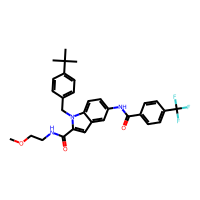
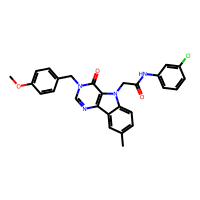
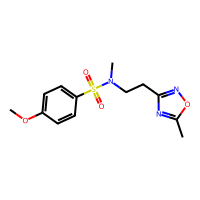
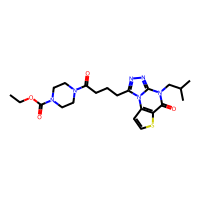
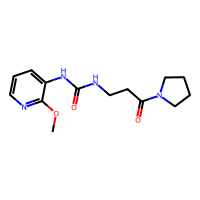
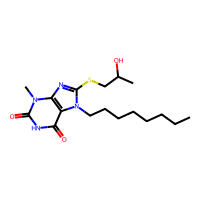
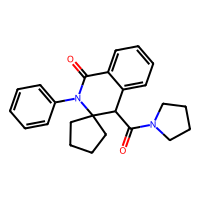
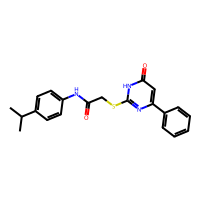
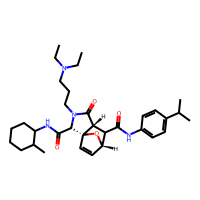
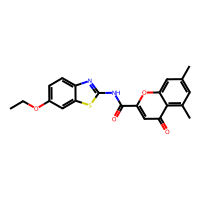

In [ ]:
#Aleatory sample of 1% of the DataFrame
sample_df = combined_df.sample(frac=0.01)
PandasTools.AddMoleculeColumnToFrame(sample_df,'Canonical_SMILES_STD','Molecule',includeFingerprints=True)
sample_df